In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
from IPython.display import display, HTML
from bs4 import BeautifulSoup
from io import StringIO
import base64
from PIL import Image
import io

In [2]:
with open('training_validation_loss.json', 'r') as f:
    df = pd.DataFrame(json.load(f)['training_validation_loss_per_epoch'])

df['training_loss'] = df['training_loss'].astype(float)
df['validation_loss'] = df['validation_loss'].astype(float)
df = df.rename(columns={'training_loss': 'train_loss', 'validation_loss': 'valid_loss', 'Dice': 'dice'})

best = df['valid_loss'].idxmin()

def make_row(r, i):
    cls = 'best' if i == best else ('even' if i % 2 == 0 else 'odd')
    vals = [int(r.epoch), f"{r.train_loss:.6f}", f"{r.valid_loss:.6f}",
            f"{r.accuracy:.6f}", f"{r.dice:.6f}", r.time]
    return f"<tr class='{cls}'>{''.join(f'<td>{v}</td>' for v in vals)}</tr>"

html = """
<style>
.ct{border-collapse:collapse;font-size:13px;font-family:monospace}
.ct th{background:#d9d9d9;text-align:center;padding:6px 16px;border:1px solid #ccc;font-weight:bold}
.ct td{text-align:center;padding:5px 16px;border:1px solid #e0e0e0}
.ct .even td{background:#f2f2f2}.ct .odd td{background:#fff}.ct .best td{background:#c6efce;font-weight:bold}
</style>
<table class='ct'><thead><tr>%s</tr></thead><tbody>%s</tbody></table>
""" % (
    ''.join(f"<th>{c}</th>" for c in ['epoch','train_loss','valid_loss','accuracy','dice','time']),
    ''.join(make_row(r, i) for i, r in df.iterrows())
)

display(HTML(html))

epoch,train_loss,valid_loss,accuracy,dice,time
0,0.378220,0.350569,0.859842,0.893774,01:05:09
1,0.381166,0.312277,0.874134,0.894629,01:05:44
2,0.332101,0.321700,0.884293,0.905590,01:04:48
3,0.324885,0.320498,0.886953,0.905654,01:04:39
4,0.319160,0.282253,0.888691,0.910301,01:05:26
5,0.313739,0.276970,0.895577,0.914859,01:06:12
6,0.315284,0.265914,0.892779,0.900329,01:03:21
7,0.287156,0.255073,0.899062,0.916217,01:03:42
8,0.296360,0.266574,0.896200,0.913766,01:03:25
9,0.300953,0.250083,0.901937,0.917763,01:03:04


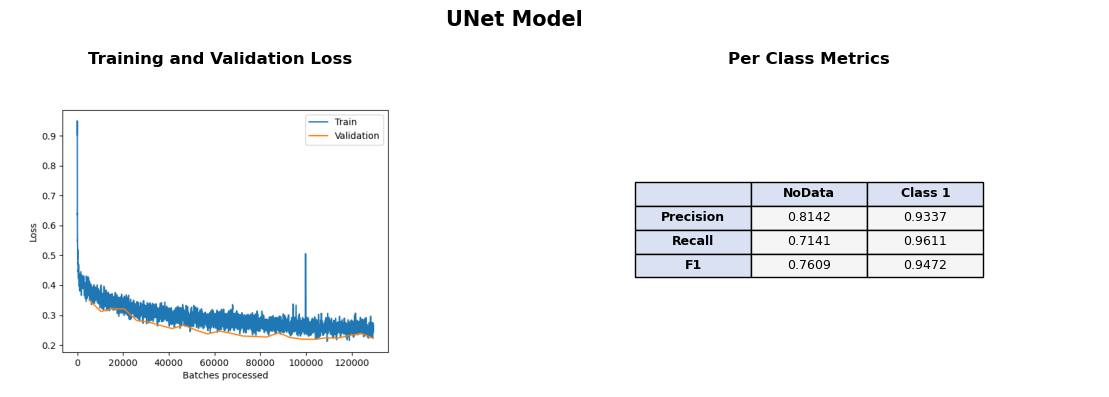

In [3]:
with open('model_metrics.html', 'r') as f:
    soup = BeautifulSoup(f.read(), 'html.parser')

# Grafik loss
img_tag = soup.find('img')
loss_img = Image.open(io.BytesIO(base64.b64decode(img_tag['src'].split(',')[1])))

# Tabel metrics
df = pd.read_html(StringIO(str(soup.find('table'))))[0]
df.columns = ['Metric', 'NoData', 'Class_1']
df = df.set_index('Metric')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(loss_img)
ax1.axis('off')
ax1.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')

ax2.axis('off')
ax2.set_title('Per Class Metrics', fontsize=12, fontweight='bold')

table_data = [
    ['', 'NoData', 'Class 1'],
    ['Precision', f"{df.loc['precision', 'NoData']:.4f}", f"{df.loc['precision', 'Class_1']:.4f}"],
    ['Recall',    f"{df.loc['recall',    'NoData']:.4f}", f"{df.loc['recall',    'Class_1']:.4f}"],
    ['F1',        f"{df.loc['f1',        'NoData']:.4f}", f"{df.loc['f1',        'Class_1']:.4f}"]
]

tbl = ax2.table(cellText=table_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(0.6, 1.4)

for (row, col), cell in tbl.get_celld().items():
    if row == 0 or col == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#d9e1f2')
    else:
        cell.set_facecolor('#f5f5f5')

plt.suptitle('UNet Model', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

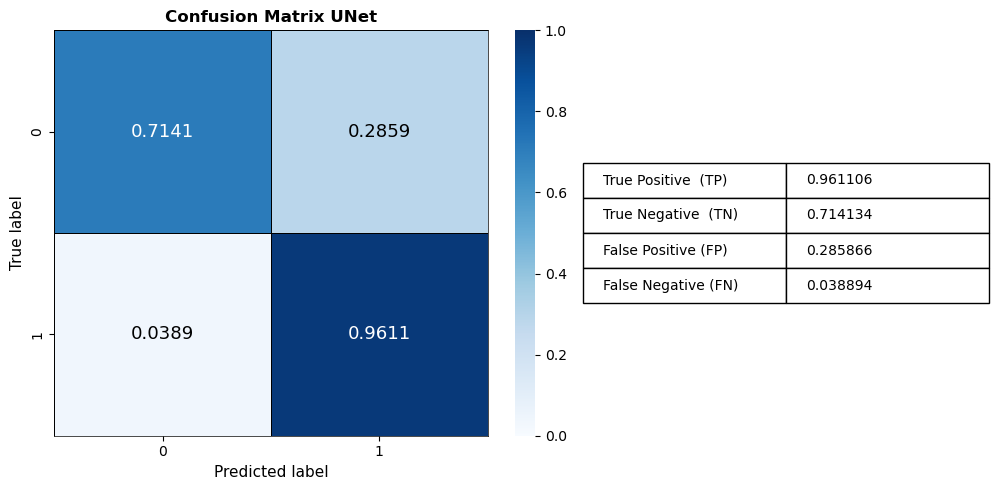

In [4]:
with open('model_metrics.html', 'r') as f:
    soup = BeautifulSoup(f.read(), 'html.parser')
    
table = soup.find('table')
df = pd.read_html(StringIO(str(table)))[0]
df.columns = ['Metric', 'NoData', 'Class_1']
df = df.set_index('Metric')

recall = df.loc['recall'].values.astype(float)
cm = np.array([[recall[0],     1 - recall[0]],
               [1 - recall[1], recall[1]]])

TP = cm[1, 1]  
TN = cm[0, 0]  
FP = cm[0, 1]  
FN = cm[1, 0] 

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 1]})

sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'],
            ax=ax, vmin=0, vmax=1,
            linewidths=0.5, linecolor='black')
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j + 0.5, i + 0.5, f'{val:.4f}',
                ha='center', va='center',
                fontsize=13, color=color)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label', fontsize=11)
ax.set_title('Confusion Matrix UNet', fontsize=12, fontweight='bold')
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('black')

ax2.axis('off')
table_data = [
    ['True Positive  (TP)', f'{TP:.6f}'],
    ['True Negative  (TN)', f'{TN:.6f}'],
    ['False Positive (FP)', f'{FP:.6f}'],
    ['False Negative (FN)', f'{FN:.6f}'],
]
tbl = ax2.table(cellText=table_data, loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.5, 2.0)

plt.tight_layout()
plt.show()